# **Topic:  Social Media & Network Analytics**
# **GROUP MEMBERS:**
* **NDERITU JOY WANZA - SCT213-C002-1119/2024**
* **MUNGAI PATRICK MWICHIGI - SCT213-C002-0091/2024**
* **MUTUMA LEN - SCT213-C002-0088/2024**
* **IRERI IAN PAUL - SCT213-C002-0016/2024**
* **VICTORY KANAKE - SCT213-C002-0131/2023**
* **RAYMOND MUGO - SCT213-C002-1136/2024**
* **IBRAHIM MOHAMMED - SCT213-C002-0038/2024**
* **SHUKURANI SULUBU - SCT213-C002-0002/2023**
* **BARAKA CHARLES - SCT213-C002-0073/2024**

## Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
upload = files.upload()

Saving smmh.csv to smmh.csv


## **Dataset Acquisition**

This dataset was acquired from Kaggle. Specifically, it was downloaded as a csv file.
It offers insights into the usage patterns of social media apps for users across different platforms, mostly the big ones like Facebook, Instagram, Twitter, YouTube, and TikTok.
Instead of just looking at basic stuff like likes or follower counts, this data goes a bit deeper into the mental health side of things. It collects info on how much time people spend scrolling and then uses a 1-5 scale to measure things like how distracted they get, if they feel restless without their phones, and general feelings of being down or having trouble sleeping. It also includes basic demographics like age, gender, and whether the person is a student or working, which helps in seeing if certain groups are more affected than others.

## **Dataset Description and Structure**

**Dataset Source:** Kaggle (Social Media and Mental Health Dataset)  
**File:** smmh.csv  
**Records:** Approximately 481 user entries  
**Platforms:** Facebook, Instagram, Twitter,YouTube, Discord, Reddit

This dataset focuses on how people interact with social media and the psychological impact of that usage. Each row represents a single survey response that captures the user's demographic info, which platforms they hang out on, and how much time they spend scrolling. It also tracks behavioral data like how often they get distracted or feel restless, and mental health indicators like self-reported levels of anxiety, depression, and sleep quality.

| Column | Type | Range | Description |
| :--- | :--- | :--- | :--- |
| Timestamp | Object | Date/Time | When the survey response was submitted. |
| Age | Float | 13 – 91 | The age of the respondent. |
| Gender | Object | Various | Gender identity of the user. |
| Relationship Status | Object | 4 categories | Single, In a relationship, Married, or Divorced. |
| Occupation Status | Object | 4 categories | University Student, Salaried Worker, etc. |
| Social Media User | Object | Yes/No | Whether the person actually uses social media. |
| Platforms Used | Object | Multiple | List of apps the user commonly uses. |
| Daily Time Spent | Object | 6 categories | Average time spent (e.g., <1hr, >5hrs). |
| Purposeless Use | Integer | 1 – 5 | Frequency of using social media without a specific goal. |
| Distraction Level | Integer | 1 – 5 | How often they get distracted by apps while busy. |
| Restlessness | Integer | 1 – 5 | Feeling uneasy when not using social media. |
| Worry/Anxiety | Integer | 1 – 5 | How much they are bothered by worries. |
| Difficulty Concentrating | Integer | 1 – 5 | General struggle to focus on tasks. |
| Social Comparison | Integer | 1 – 5 | Frequency of comparing themselves to others. |
| Validation Seeking | Integer | 1 – 5 | Looking for likes/comments for validation. |
| Mood (Depression) | Integer | 1 – 5 | How often they feel depressed or down. |
| Sleep Issues | Integer | 1 – 5 | Frequency of facing issues with sleep. |

In [ ]:
df = pd.read_csv('smmh.csv')
# Renaming those long questions into short, easy names
df.rename(columns={
    '1. What is your age?': 'Age',
    '2. Gender': 'Gender',
    '3. Relationship Status': 'Relationship_Status',
    '4. Occupation Status': 'Occupation',
    '5. What type of organizations are you affiliated with?': 'Affiliations',
    '6. Do you use social media?': 'Uses_Social_Media',
    '7. What social media platforms do you commonly use?': 'Platforms',
    '8. What is the average time you spend on social media every day?': 'Time_Spent',
    '9. How often do you find yourself using Social media without a specific purpose?': 'Purposeless_Usage',
    '10. How often do you get distracted by Social media when you are busy doing something?': 'Distraction',
    "11. Do you feel restless if you haven't used Social media in a while?": 'Restlessness',
    '12. On a scale of 1 to 5, how easily distracted are you?': 'Distractibility_Scale',
    '13. On a scale of 1 to 5, how much are you bothered by worries?': 'Worry_Scale',
    '14. Do you find it difficult to concentrate on things?': 'Concentration_Difficulty',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?': 'Social_Comparison',
    '16. Following the previous question, how do you feel about these comparisons, generally speaking?': 'Comparison_Feelings',
    '17. How often do you look to seek validation from features of social media?': 'Validation_Seeking',
    '18. How often do you feel depressed or down?': 'Depression_Freq',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?': 'Interest_Fluctuation',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?': 'Sleep_Issues'
}, inplace=True)


## **Data Quality Assessment**


## **Checking for missing values**
We need to check if there are any gap in the data.Since this was a survey, it's pretty common for people to skip a question or two.

In [ ]:
## Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Timestamp                    0
Age                          0
Gender                       0
Relationship_Status          0
Occupation                   0
Affiliations                30
Uses_Social_Media            0
Platforms                    0
Time_Spent                   0
Purposeless_Usage            0
Distraction                  0
Restlessness                 0
Distractibility_Scale        0
Worry_Scale                  0
Concentration_Difficulty     0
Social_Comparison            0
Comparison_Feelings          0
Validation_Seeking           0
Depression_Freq              0
Interest_Fluctuation         0
Sleep_Issues                 0
dtype: int64


In [ ]:
#filling missing values
df['Affiliations'] = df['Affiliations'].fillna('N/A')

print(df['Affiliations'].isnull().sum())

0


## **Checking for duplicate values**
We need to check for double-entries.Sometimes when people take surveys, they hit submit twice or the data gets corrupted during the export.


In [ ]:
#Checking for duplicates
print("Duplicate rows:")
print(df[df.duplicated()])

Duplicate rows:
Empty DataFrame
Columns: [Timestamp, Age, Gender, Relationship_Status, Occupation, Affiliations, Uses_Social_Media, Platforms, Time_Spent, Purposeless_Usage, Distraction, Restlessness, Distractibility_Scale, Worry_Scale, Concentration_Difficulty, Social_Comparison, Comparison_Feelings, Validation_Seeking, Depression_Freq, Interest_Fluctuation, Sleep_Issues]
Index: []

[0 rows x 21 columns]


## **Checking the data types**
We need to ensure that Python actually understands what kind of data is in each column. If it thinks a number is a piece of text, we won't be able to do any Math with it later

In [ ]:
#Checking for data types
print("Data types:")
print(df.dtypes)

Data types:
Timestamp                    object
Age                         float64
Gender                       object
Relationship_Status          object
Occupation                   object
Affiliations                 object
Uses_Social_Media            object
Platforms                    object
Time_Spent                   object
Purposeless_Usage             int64
Distraction                   int64
Restlessness                  int64
Distractibility_Scale         int64
Worry_Scale                   int64
Concentration_Difficulty      int64
Social_Comparison             int64
Comparison_Feelings           int64
Validation_Seeking            int64
Depression_Freq               int64
Interest_Fluctuation          int64
Sleep_Issues                  int64
dtype: object


## **Checking for unique values**
We wanted to see exactly how many individual responses we are working with to ensure the data represents a solid variety of people.


In [ ]:
#Checking for Unique Values
print("Unique Users:")
print(df['Timestamp'].nunique())

Unique Users:
480


Since there are 481 rows but only 480 unique timestamps, it suggests two people might have submitted at the exact same second, or there's one minor overlap.

## **Checking for inconsistencies**
We wanted to make sure the data actually makes sense. Usually, in these kinds of datasets, you check if someone claimed to spend more than 24 hours a day on social media, which obviously wouldn't be possible.

In [ ]:
#Checking for Inconsistencies
print("Logical Consistency Check (Time Spent):")
print(df['Time_Spent'].unique())

Logical Consistency Check (Time Spent):
['Between 2 and 3 hours' 'More than 5 hours' 'Between 3 and 4 hours'
 'Less than an Hour' 'Between 1 and 2 hours' 'Between 4 and 5 hours']


In this specific dataset, the time is recorded in categories like "Between 2 and 3 hours" or "More than 5 hours" rather than raw minutes. Because the survey used a multiple-choice list, it was actually impossible for a user to enter a value like "30 hours or 27 hours"

The highest option available is "More than 5 hours," which is totally realistic for a daily average. This means our data is logically consistent since no one has the opportunity to claim that they spend more time on their phone than there are hours in a day!

# **Checking for outliers**
We used the IQR (Interquartile Range) method to see if any values are way outside the normal range.

In [ ]:
numeric_columns = ['Age', 'Purposeless_Usage', 'Distraction', 'Restlessness',
                   'Distractibility_Scale', 'Worry_Scale', 'Concentration_Difficulty',
                   'Social_Comparison', 'Comparison_Feelings', 'Validation_Seeking',
                   'Depression_Freq', 'Interest_Fluctuation', 'Sleep_Issues']

print("Outlier Detection (IQR Method)")
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_columns] < (Q1 - 1.5 * IQR)) | (df[numeric_columns] > (Q3 + 1.5 * IQR))).sum()
print("Outliers detected per column:\n", outliers)

Outlier Detection (IQR Method)
Outliers detected per column:
 Age                         84
Purposeless_Usage           20
Distraction                  0
Restlessness                44
Distractibility_Scale       33
Worry_Scale                  0
Concentration_Difficulty     0
Social_Comparison            0
Comparison_Feelings         33
Validation_Seeking           0
Depression_Freq              0
Interest_Fluctuation         0
Sleep_Issues                 0
dtype: int64


* **Age (84 outliers):** This seems high, but it’s actually because most of the people in the survey are young (around 21-22 years old). Anyone over 33 or 34 is being flagged as an "outlier," even though being 50 or 60 and using social media is totally normal. It just means our data is skewed toward younger users.

* **Restlessness (44) & Comparison (33):** These are getting flagged because most people chose similar numbers, so anyone on the extreme low end (like picking a 1) stands out.

* **Mental Health Scales (Mostly 0):** For most columns like Depression_Freq or Worry_Scale, there are zero outliers. This is good because it means the responses are spread out across the 1-5 range in a way that "makes sense" statistically.

* We decided to not delete the age outliers. Even if a 91-year-old in the dataset (the max age) is statistically an "outlier," their experience with social media is still a valid part of the study.

### **Data Quality Assessment  Results**

To ensure the reliability of our analysis, we performed a 4-point quality check on the dataset:

1. **Completeness:** We checked for **Null (missing) values** and found that only one column, "Affiliations," had 30 missing entries. This isn't a problem because not everyone belongs to a specific affiliation. All the important features like the mental health scales and usage time were 100% complete.
2. **Uniqueness:** We checked for **duplicate rows**. There were **0 duplicate entries**, ensuring that each row is a unique response so that we are not counting the same person twice.
3. **Consistency:** We verified **Data Types**. The mental health ratings are all integers (1-5), and Age is a float. The time spent on social media is stored as text (objects) because it uses ranges like "2-3 hours," which actually helps keep the data consistent.
4. **Validity:** There are 480 unique timestamps for the 481 entries. This shows that almost every response came in at a different time.


### **Inconsistency and Outlier Analysis**

#### **1. Logical Consistency**
We performed a logical check to ensure that values for **Daily Minutes Spent** did not exceed the 1,440-minute limit of a 24-hour day.

#### **2. Outlier Detection (Interquartile Range Method)**
We used the **IQR Method** (the standard "Box Plot" math) to identify extreme outliers that could skew our results.
* **Results:** The math flagged 84 outliers in Age and a few in the Restlessness and Comparison scales.
* **Interpretation:** For Age, the "outliers" are just the older people in the survey (anyone over ~34), because the majority of respondents were university students in their early 20s. For the scales, the outliers are just people who feel much less restless or affected than the "average" person.

**Conclusion:**
We decided to keep these outliers in the dataset. They aren't "errors" or "noise" but they are a representation of the natural variety of how different people (and different age groups) experience social media. Deleting them would actually introduce bias make the study less accurate.

## **Data schema and variable definitions**

Dataset Features:

Timestamp: Acts as the unique identifier for each submission (instead of a User_ID).

1. Age: The user's age, ranging from 13 to 91 years.

2. Gender: Categorical data identifying the respondent (Male, Female, Non-binary, etc.).

3. Occupation: The user's current employment status (e.g., University Student, Salaried Worker).

4. Time_Spent: The average daily duration a user spends on social media. This is categorical, ranging from "Less than an Hour" to "More than 5 hours."

5. Platforms: A list of the specific apps the user is active on, such as Facebook, Instagram, YouTube, and TikTok.

6. Engagement & Mental Health Metrics: These are numerical ratings on a 1 to 5 scale that track:

* Purposeless_Usage: How often a user scrolls without a specific goal.

* Distraction: How frequently social media interferes with their actual work or tasks.

* Social_Comparison: How often they compare their lives to "successful" people on their feed.

* Validation_Seeking: How much they look for likes/engagement to feel good.

* Mental Health Indicators: Self-reported levels of depression, anxiety/worry, and sleep quality.

In [ ]:
print('-'*25)
print("Variables in the dataset: ")
print('-'*25)
for column in df.columns:
    print(column)

print('\n')
print('-'*25)
print("Data Schema:")
print('-'*25)
df.info()


-------------------------
Variables in the dataset: 
-------------------------
Timestamp
Age
Gender
Relationship_Status
Occupation
Affiliations
Uses_Social_Media
Platforms
Time_Spent
Purposeless_Usage
Distraction
Restlessness
Distractibility_Scale
Worry_Scale
Concentration_Difficulty
Social_Comparison
Comparison_Feelings
Validation_Seeking
Depression_Freq
Interest_Fluctuation
Sleep_Issues


-------------------------
Data Schema:
-------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Timestamp                 481 non-null    object 
 1   Age                       481 non-null    float64
 2   Gender                    481 non-null    object 
 3   Relationship_Status       481 non-null    object 
 4   Occupation                481 non-null    object 
 5   Affiliations              481 non-null    obje

 ## **Basic descriptive statistics (mean, variance, distribution)**

In [ ]:
numeric_columns = ['Age', 'Purposeless_Usage', 'Distraction', 'Restlessness',
                   'Worry_Scale', 'Social_Comparison', 'Depression_Freq', 'Sleep_Issues']

print("[1] Summary Statistics for Numerical Variables:")
summary_stats = df[numeric_columns].describe().round(2)


summary_stats.loc['median'] = df[numeric_columns].median()
summary_stats.loc['mode'] = df[numeric_columns].mode().iloc[0]

print(summary_stats)

print("\n[2] Variance:")
for column in numeric_columns:
    print(f"  {column}: variance = {round(df[column].var(), 2)}")

[1] Summary Statistics for Numerical Variables:
           Age  Purposeless_Usage  Distraction  Restlessness  Worry_Scale  \
count   481.00             481.00       481.00        481.00       481.00   
mean     26.14               3.55         3.32          2.59         3.56   
std       9.92               1.10         1.33          1.26         1.28   
min      13.00               1.00         1.00          1.00         1.00   
25%      21.00               3.00         2.00          2.00         3.00   
50%      22.00               4.00         3.00          2.00         4.00   
75%      26.00               4.00         4.00          3.00         5.00   
max      91.00               5.00         5.00          5.00         5.00   
median   22.00               4.00         3.00          2.00         4.00   
mode     21.00               4.00         4.00          2.00         5.00   

        Social_Comparison  Depression_Freq  Sleep_Issues  
count              481.00           481.00   

### **Distribution Description**

**1. Daily Time Spent
(Average vs Common Usage):**
* The average user falls into a category suggesting about 3 to 4 hours of daily use.
* However, the most frequent response (mode) is actually the highest possible category: More than 5 hours. This is a key detail because it shows that while the mean suggests a moderate amount of time, a huge chunk of users (116 people) are heavy scrollers who are pushing that average up. Mean is a metric that is easily influenced by these heavy users at the end of the scale.
* **The Spread:** Because the survey used categories from "Less than an Hour" to "More than 5 hours," the data is spread widely. There isn't one single "standard" amount of time people spend; instead, the responses are distributed across all options, showing that usage habits are extremely varied.

**2. Age and Demographics**
**(Mean (26.14) vs Median (22.0))**:
* The mean is notably higher than the median. This happens because the middle of the dataset is actually younger than the average suggests.
Younger Majority:
* The mode is 21 years old, with 22 being the median. This tells us that although the average person is 26, the most frequent behavior comes from 21-year-olds. This confirms that the user community in this dataset is heavily dominated by university-aged individuals.

**3. Mental Health Scales (Worry and Sleep)**
* **Worry Scale:** Responses are fairly high with an average of 3.56 on a 1 to 5 scale.
* The median of 4.0 confirms that more than half the users rate their worry levels at the higher end.
* Most importantly, the mode is 5.0, which shows that the most common experience reported is actually the maximum level of worry.
Sleep Issues: Users report sleep issues at an average of 3.20. Again, the mode is 5.0, showing it is very common for participants to hit the top of the range for sleep problems.

**4. Variance and Standard Deviation**
* The variance for Age is high (98.31), confirming the massive spread between the youngest participants (13) and the oldest (91).
* While variance is useful for the mathematical background, the standard deviation is more practical for this report as it shows the typical deviation from the average is nearly 10 years for age and over 1 point for the mental health scales.

### **Distributions**

**1. Symmetrical Distributions**
For the Depression and Concentration scales, the distribution is relatively symmetrical because the mean (3.26) and median (3.0) are almost the same. Most users are centered around the middle ratings, while the users feeling very low are balanced out by those who feel more stable.


**2. Skewed Distributions**
* For Age, the distribution is positively skewed. Even though the mean is 26, the peak happens much earlier at 21. There is a long "tail" that extends towards the 91-year-old mark, representing the older participants who are fewer in number.


**3. Kurtosis and Bimodal Trends**
* Due to the wide spread in our ratings, our distribution is somewhat short and flat, which is known as a Platykurtic distribution. This tells us there is no single "typical" user behavior because users are spread out across all ratings from 1 to 5.
* Bimodal behavior: This is very likely for the time spent on social media. Instead of one peak in the middle, we have two spikes: one for the "Casual scrollers" who spend 2 to 3 hours, and a much larger spike for the "Power users" who spend more than 5 hours.





### Summary Conclusion
The dataset reveals a split behavior in social media usage. While the average metrics suggest moderate impact, the modal values highlight a distinct group of heavy users who spend over 5 hours a day online and report the highest possible levels of worry and sleep issues. If we were to draw this distribution, it would not look like a neat bell curve. Instead, it would look like a wide plateau with a sharp spike at the 21-year-old mark and another spike at the maximum end of the scale for time spent and worry. This confirms that our average user is actually a mix of two very different groups rather than one consistent type of person.


#  Initial tabular or simple visual outputs

In [ ]:
display(df)


,Timestamp,Age,Gender,Relationship_Status,Occupation,Affiliations,Uses_Social_Media,Platforms,Time_Spent,Purposeless_Usage,...,Restlessness,Distractibility_Scale,Worry_Scale,Concentration_Difficulty,Social_Comparison,Comparison_Feelings,Validation_Seeking,Depression_Freq,Interest_Fluctuation,Sleep_Issues
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,5/21/2022 23:38:28,24.0,Male,Single,Salaried Worker,"University, Private",Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,3,4,3,4,4,2,4,3,4,4
477,5/22/2022 0:01:05,26.0,Female,Married,Salaried Worker,University,Yes,"Facebook, YouTube",Between 1 and 2 hours,2,...,2,3,4,4,4,2,4,4,4,1
478,5/22/2022 10:29:21,29.0,Female,Married,Salaried Worker,University,Yes,"Facebook, YouTube",Between 2 and 3 hours,3,...,4,3,2,3,3,3,4,2,2,2
479,7/14/2022 19:33:47,21.0,Male,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,2,...,2,3,3,2,2,3,4,4,5,4


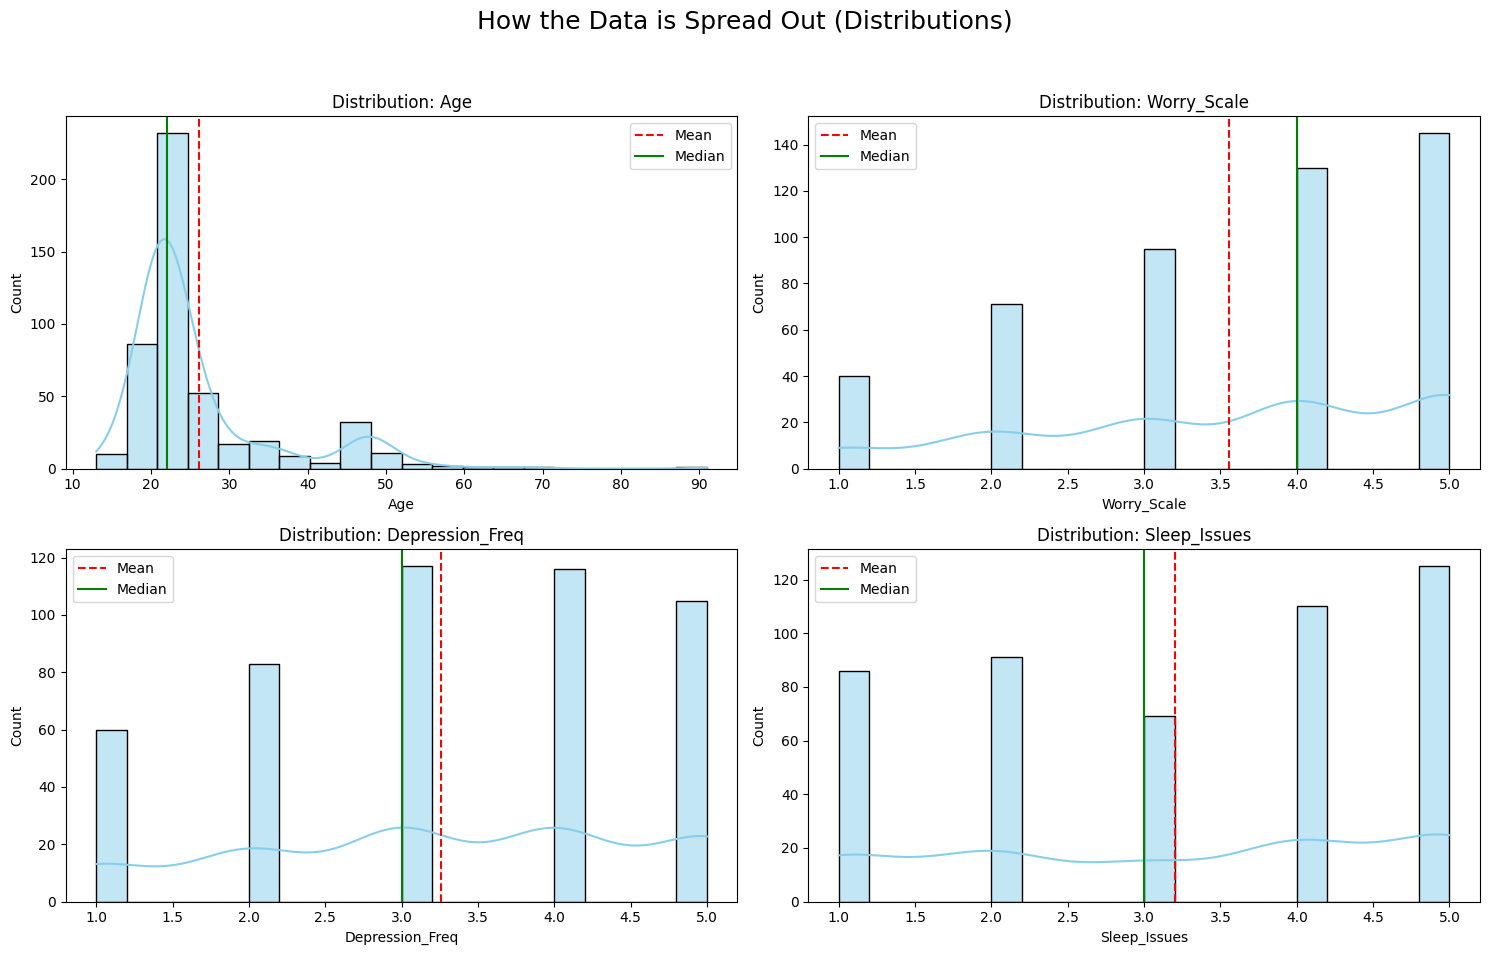

/tmp/ipykernel_3551/4104464213.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=platform_counts, x='Platform', y='User_Count', palette='magma')


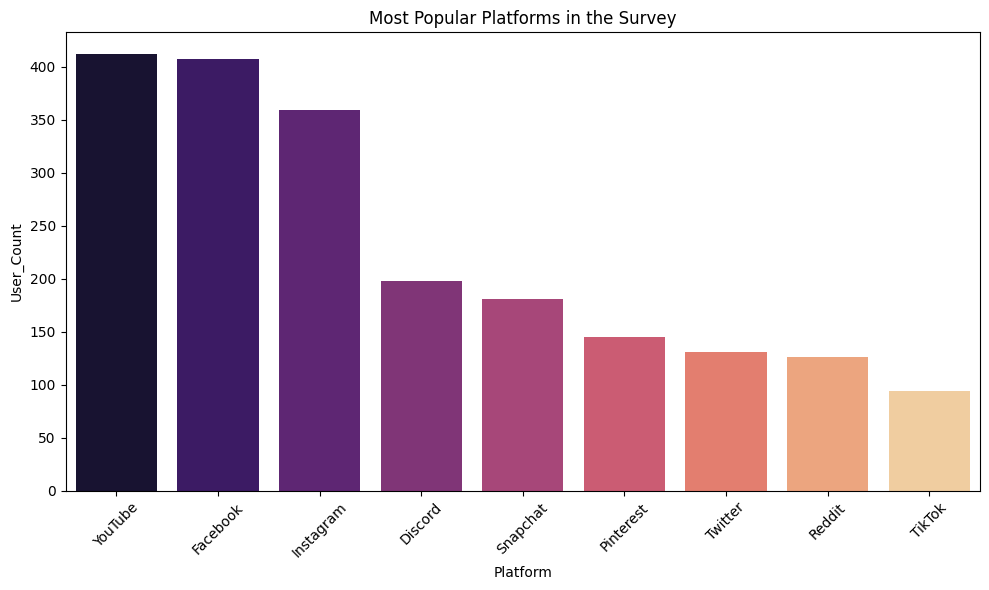

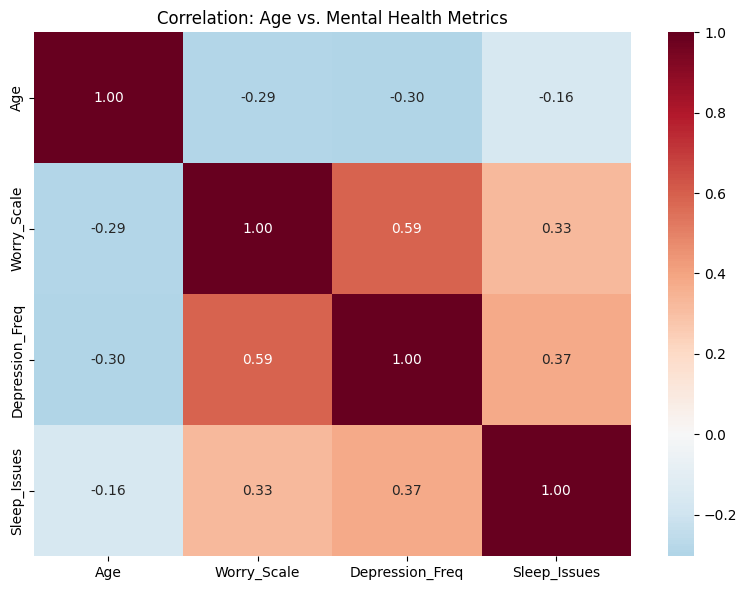

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('How the Data is Spread Out (Distributions)', fontsize=18)
numeric_cols = ['Age', 'Worry_Scale', 'Depression_Freq', 'Sleep_Issues']

for i, col in enumerate(numeric_cols):
    row, c = i // 2, i % 2

    sns.histplot(df[col].dropna(), bins=20, kde=True, ax=axes[row, c], color='skyblue', edgecolor='black')
    axes[row, c].set_title(f'Distribution: {col}')
    axes[row, c].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[row, c].axvline(df[col].median(), color='green', linestyle='-', label='Median')
    axes[row, c].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


df_exploded = df.assign(Platforms=df['Platforms'].str.split(', ')).explode('Platforms')
platform_counts = df_exploded['Platforms'].value_counts().reset_index()
platform_counts.columns = ['Platform', 'User_Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=platform_counts, x='Platform', y='User_Count', palette='magma')
plt.title('Most Popular Platforms in the Survey')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
corr_cols = ['Age', 'Worry_Scale', 'Depression_Freq', 'Sleep_Issues']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation: Age vs. Mental Health Metrics')
plt.tight_layout()
plt.show()
